## Notebook para visualizar el espacio latente de distintos modelos

2026-02-25 14:29:59.485352: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Usando mnist como dataset


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


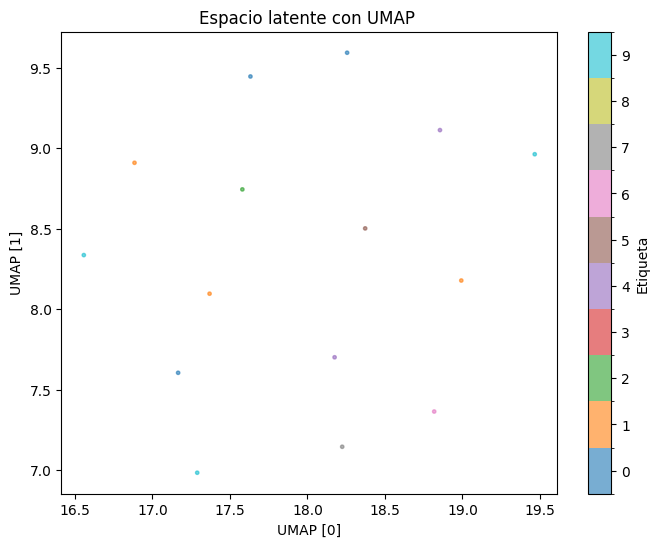

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader

import project.visualizations.visualizations as vis
import tensorflow as tf

DATASET="mnist" # mnist o fashion
N_POINTS=15 # Cantidad de puntos a visualizar


#Puede ser cualquiera de los modelos entrenados
cvae = Loader.cvae(lat=64, inter=128, dataset=DATASET)

data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)


x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]

test_dataset = tf.data.Dataset.from_tensor_slices(((x_test, y_test), x_test))


vis.latent_space_umap(cvae, test_dataset, n_points=N_POINTS,label_names=labels, title= cvae.name)






Encontrados 9 pares de modelos.
model: cvae_1024_lat_256_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


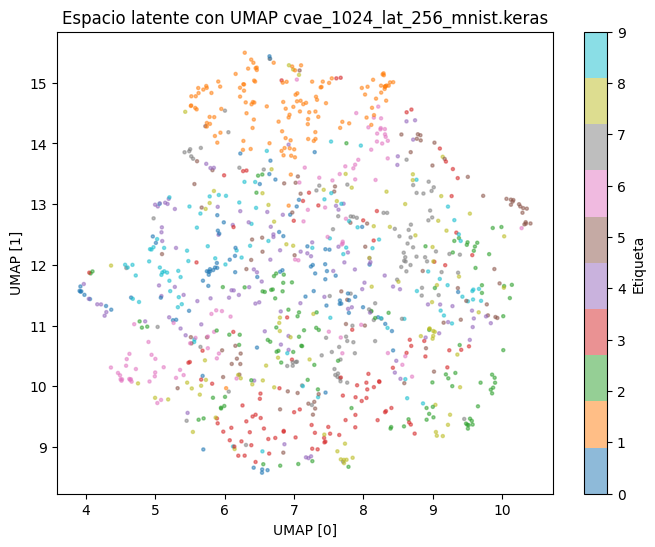

model: cvae_1024_lat_512_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


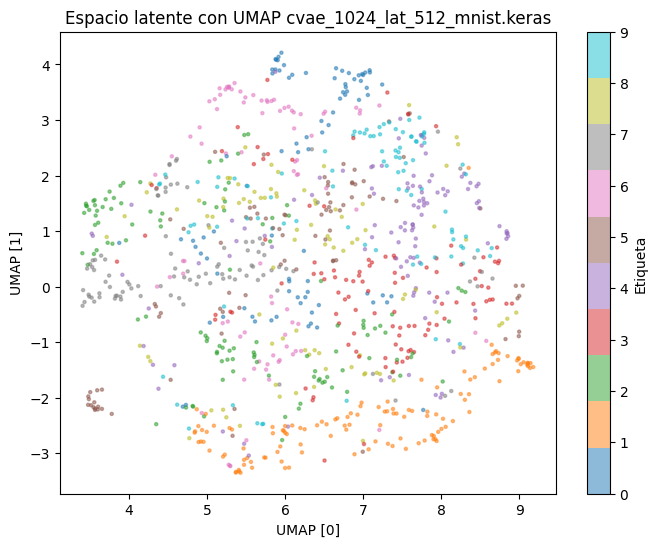

model: cvae_128_lat_2_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


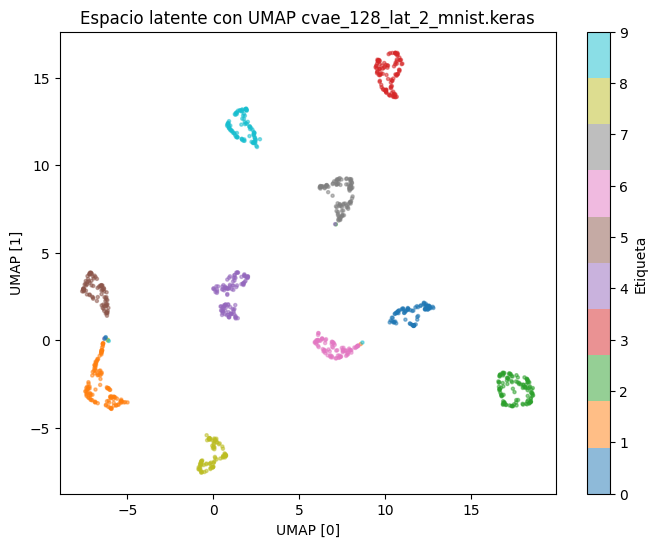

model: cvae_128_lat_64_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


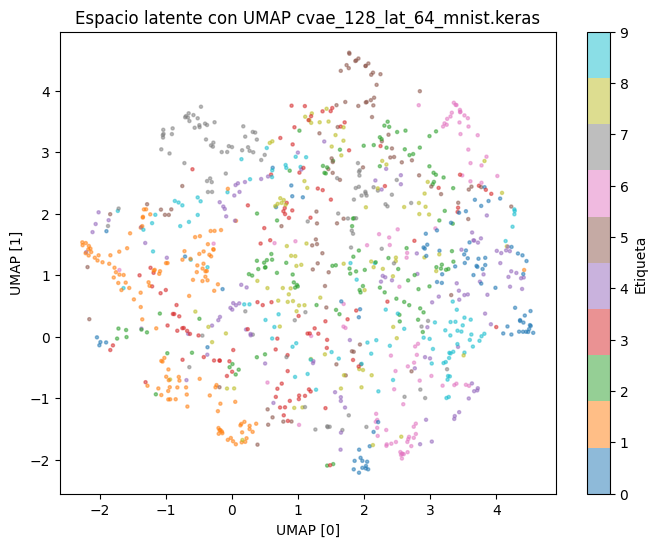

model: cvae_256_lat_128_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


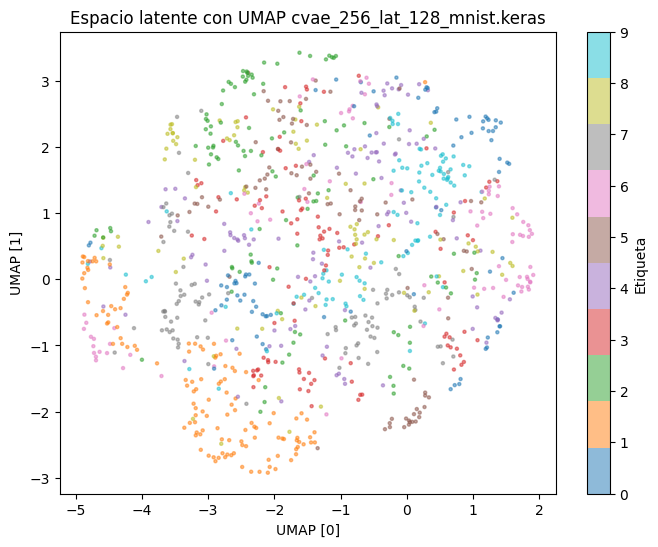

model: cvae_256_lat_64_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


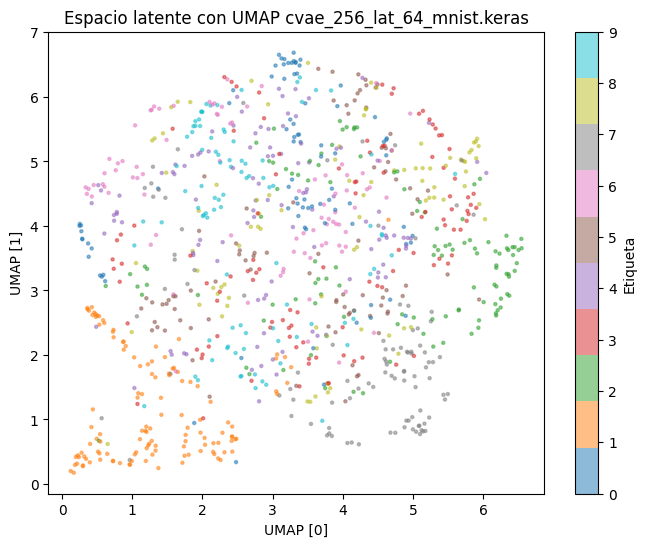

model: cvae_512_lat_128_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


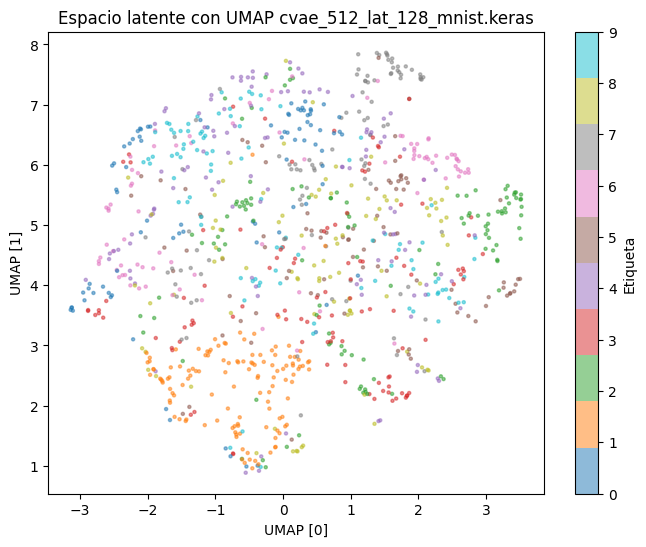

model: cvae_512_lat_256_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


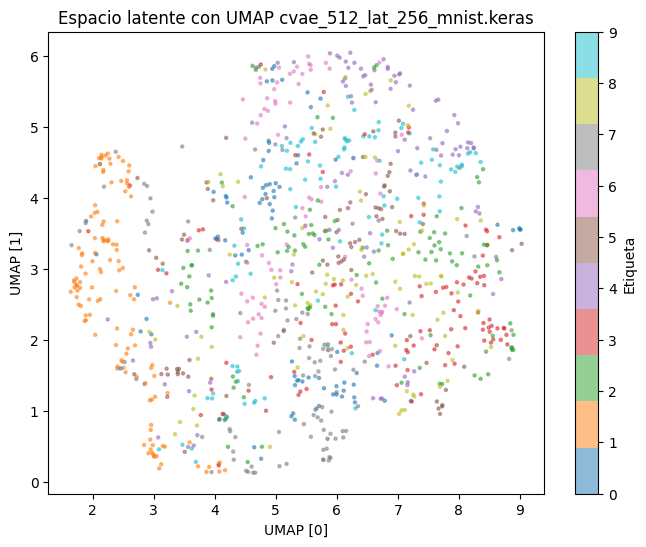

model: cvae_784_lat_784_mnist.keras 



/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


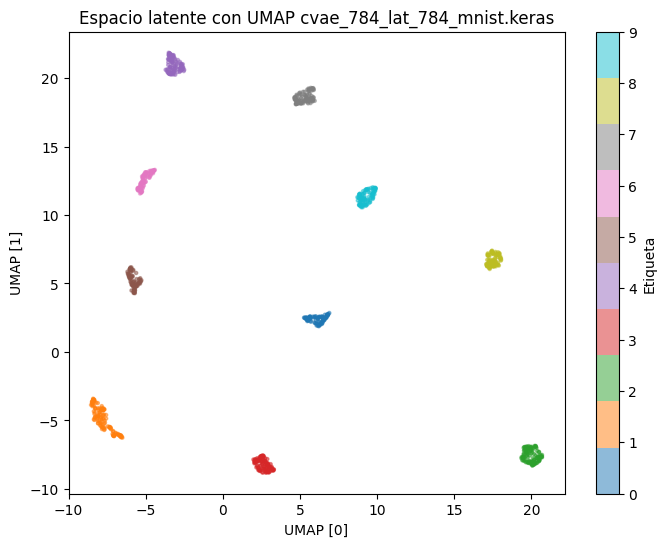

In [7]:
models=load.all_models(dataset="mnist")

val_dataset = tf.data.Dataset.from_tensor_slices(((x_test, y_test), x_test))

#save_path=f"figs/umap_latente_{m.name}.png"
for m in models:
    print(f"model: {m.name} \n")
    vis.latent_space_umap(m, val_dataset, max_samples=1000  ,title=m.name)



Los gráficos no muestran espacios latentes con estructura. pero no parece afectar, al rendimiento a la hora de separa digitos. ¿Es un error de visaulización o de entrenamiento?
Los espacios latentes no tiene estrucutra dado que es la concatenación de z(64 128,...) y labels(10). En el caso de dim_lat = 2, los labels tienen mucho peso. y conforme crece el espacio latente los labels pierden peso. 